# <font color=#2e86c1> SLEEPY Tutorial </font>
*Spins in Liouville space for rElaxation and Exchange in PYthon*

## Why another simulation program?
SLEEPY is NMR simulation software that is focused on simulations under dynamic conditions, where dynamics effects are introduced via exchange processes that stochastically modulate terms in the Hamiltonian. These are the types of processes that lead to *relaxation*: $T_1$, $T_2$, $T_{1\rho}$, NOE, etc. We think relaxation is important, so we wanted to make it easier to simulate it!

### How does it compare to other software?
* [SIMPSON](https://inano.au.dk/about/research-centers-and-projects/nmr/software/simpson)

  Compared to SIMPSON, SLEEPY will almost always be slower, and for good reason. SLEEPY operates in *Liouville space*, which requires matrices significantly larger than the *Hilbert space* matrices used in SIMPSON, e.g. when the Hilbert space matrix is $m\times m$, the Liouville space matrix is $m^2\times m^2$. This is the cost of including exchange, which cannot be introduced easily in Hilbert space. SLEEPY was designed to accept similar inputs as SIMPSON, although this happens now in a Python (ideally interactive!) environment rather than TCL.
  

* [Spinach](https://spindynamics.org/?page_id=12)

  Spinach is a general purpose NMR simulation software running in MATLAB, with full relaxation and dynamics capabilities. We guess that if you can simulate it in SLEEPY, it should also be possible in Spinach. We'd also bet that the same simulation in SLEEPY and Spinach would require a lot less coding in SLEEPY. SLEEPY is also more focused on interacive coding, i.e. creating a code object, possibly inspecting it, and combining it with other code objects to create a simulation.  
  

* [SpinEvolution](https://spinevolution.com/)

  SpinEvolution is fast, powerful software for NMR dynamics simulations. It is also behind a significant paywall, where dynamics simulations require a $1650 annual subscription. We think SLEEPY has a wider range of dynamics capabilities, but we weren't interested in paying the annual fee to make sure.....
  

There's a lot else out there: these are three of the most well-known. For getting familiar with dynamic effects, however, we think SLEEPY is a great place to start.

## What do I need to define for a simulation to work?
1. **Experimental conditions, Spin system**

    Experimental conditions: Magnetic field, spinning frequency, rotor angle, temperature, powder average, etc.

    Spin system: Nuclei, interactions, lab frame or rotating frame

    *These are defined by the `ExpSys` object*

2. **Dynamics and Relaxation**
    
    Add an exchange matrix to couple changing interactions (define two or more ExpSys objects), add relaxation if needed. Note that most simulations do not include these effects, so this will be the least familiar part of SLEEPY if you've done NMR simulation before.

    *These are defined via the `Liouvillian`, which is created from one or more ExpSys objects*

3. **Pulse sequence**

    Add continuous irradiation fields or time-dependent pulse sequences.

    *This is defined via the `Sequence`, which is created from the Liouvillian*

4. **Density matrix and detection operator(s)**

    Define where the spin-system starts, and what to detect

    *This is defined by the `Rho` object*

In [4]:
import sys
sys.path.append('/Users/albertsmith/Documents/GitHub.nosync/')
sys.path.append('/Users/albertsmith/Documents/GitHub/')

### Python imports

**Jupyter Notebook/Google Colab Tip:** Notesbooks have "cells". There are code cells and text (Markdown) cells. Both types of cells are executed by pressing Shift+Enter. A code cell will run the code, and a text cell will interpret the Markdown input. Note that code cells can be run out of order, but you may mess up the output if you're not careful when running out of order. 

In [5]:
import SLEEPY as sl
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.size']=14

Loading Defaults from file


**Python Tip:** A Python session usually starts with module imports, see above. SLEEPY is the module we developed, which contains a lot of functions and objects used for simulating the impact of dynamics on NMR experiments. "sl" is the abbreviation we use for it in our code, which is just faster to type than SLEEPY. numpy is a module with lots of tools for doing matrix mathematics. matplotlib.pyplot is a submodule of Matplotlib for making nice plots. You can install and then import any module you like to use in combination with SLEEPY (e.g. import your experimental data with [nmrglue](http://127.0.0.1:8888/tree?token=524457c1a2cf549f68815e6adc33e11b78f1351c50be77f2) and then simulate it with SLEEPY within one Python terminal). numpy and pyplot are very frequently used for scientific programming, and so most of our scripts include importing these. Functions and classes found within a module are accessed by typing the module abbreviation followed by a period (.), and ending with the desired function/class/etc. from the module. For example, below we access the physical constants used in SLEEPY.

In [6]:
sl.Constants

{'h': 6.62607015e-34,
 'kB': 1.380649e-23,
 'mub': -13996244936.072704,
 'ge': 2.0023193043609235,
 'mun': 7622593.158495312,
 'mu0': 1.256637e-06}

## Example 1: Chemical Exchange
Chemical exchange is perhaps the simplest example of the influence of dynamics in NMR. We have a molecule that changes structure, resulting in the modulation of the chemical shift between two or more states. If this process is fast, then only one peak appears at the averaged chemical shift, and if it is slow, two peaks arise, one for each chemical shift. If the process approximately matches the chemical shift difference, then a broad peak arises.

### Define the experimental conditions
The ExpSys *[class](https://en.wikipedia.org/wiki/Class_(programming))* defines *[objects](https://en.wikipedia.org/wiki/Object_(computer_science))* which contain information about the experimental conditions. For example:
* Magnetic field (`ex.B0`)
* Nuclei (`ex.Nucs`)
* Spinning speed (`ex.vr`)
* Spins (`ex.S`)
* Temperature (`ex.T`)
* Interactions (`ex.CS` gives a list of chemical shifts)
* Spin operators (`ex.Op`: index first to select spin, then gives x, y, z, etc.)

In [4]:
ex=sl.ExpSys(v0H=500,Nucs=['1H'])  #Magnetic field, Nuclei in system
ex.set_inter('CS',i=0,Hz=500)      #Interaction type, spin index (use i0,i1 for spin-spin coupling)
                                   #Here, defined in Hz. Set ppm= to define in ppm

1-spin system (1H)
B0 = 11.743 T (500.000 MHz 1H frequency)
rotor angle = 54.736 degrees
rotor frequency = 10.0 kHz
Temperature = 298 K
Powder Average: JCP59 with 99 angles
Interactions:
	CS on spin 0 with arguments: (Hz=500.00)


Check various experimental parameters below. You can type `ex.` and then press the tab key to access autocompletions, or type `dir(ex)` to see all *attributes* of ex. Note, you'll access functions attached to the ExpSys object as well.

**Python tip:** Typing `dir(ex)` will reveal many attributes that start with one or two underscores (`_XXX`, `__XXX__`), whereas tab will not. These are hidden variables (`_XXX`) or dunder methods (`__XXX__`). While you're welcome to explore what's in these variables, editing them directly has a good chance of breaking SLEEPY. That's why we hid them! For example, if you adjust `ex.rotor_angle`, SLEEPY will reset calculations of tensors (e.g. dipole, CSA), because these change with the rotor angle. If you adjust `ex._rotor_angle`, these resets won't occur and your simulation will be incorrect.

In [5]:
ex.CS

[{'Type': 'CS', 'i': 0, 'Hz': 500}]

**SLEEPY tip:** If you don't know what interactions are available, or what arguments they require, type `ex.list_interactions`. `i` or `i0`/`i1` are always required, and we have to define the magnitude of the interaction. Euler angles can be omitted, yielding $\alpha=0,\beta=0,\gamma=0$. `euler` is defined in radians, but can be replaced by `euler_d`, which is in degrees. `ppm` and `Hz` both define the `CS` magnitude, just in different units (`delta` and `deltaHz` are similarly defined for the CSA, and `Cq`, `delta`, and `DelPP` all define the quadrupole magnitude).

In [6]:
ex.list_interactions

CS, with args:
	i,ppm,Hz
CSA, with args:
	i,delta,deltaHz,eta,euler
J, with args:
	i0,i1,J
ZeroField, with args:
	i,D,E,euler
dipole, with args:
	i0,i1,D,delta,eta,euler
g, with args:
	i,gxx,gyy,gzz,euler
hyperfine, with args:
	i0,i1,Axx,Ayy,Azz,euler
quadrupole, with args:
	i,order,Cq,delta,DelPP,eta,euler


Before we go on, we will check what the Hamitonian and Liouvillian look like. The Hamiltonian for a 1 spin-1/2 system is a pretty simple 2x2 matrix, whereas the Liouvillian expands into a 4x4 matrix. This Hamiltonian only leads to phase oscillation of the coherences, so we only obtain two non-zero values on the Liouvillian diagonal.

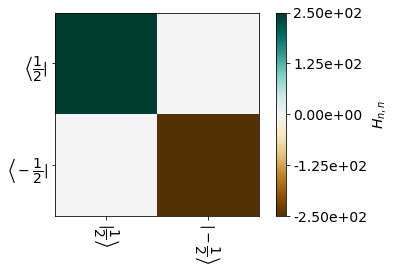

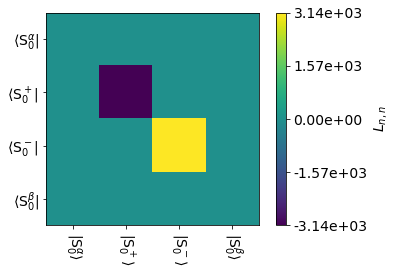

In [7]:
H=ex.Hamiltonian()  #Create the Hamiltonian
H.plot(mode='re')   #Plot the Hamiltonian, real part (most SLEEPY objects have some kind of plotting)
L=ex.Liouvillian()  #Create the Liouvillian
_=L.plot(mode='im')   #Plot the Liouvillian, imaginary part

### Add dynamics
To add dynamics, we first need something to change! So, we define a second ExpSys object with a different chemical shift. Rather than retyping all the experimental systems, we copy the first ExpSys object (`ex1=ex.copy()`). This saves us some time, but also links together some settings of the systems in case you decide to change something.

In [8]:
ex1=ex.copy()
_=ex1.set_inter('CS',i=0,Hz=100)  #Suppress text output by setting equal to _

Now, we combine the two systems into a Liouvillian, and plot the result

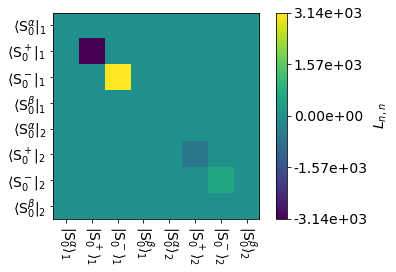

In [9]:
L=sl.Liouvillian(ex,ex1)
_=L.plot(mode='im')

The upper right contains the first Liouvillian, and the lower left contains the second. But, we're not done, because we'd like these to exchange. This is achieved by setting the exchange matrix for the Liouvillian. Since we have two states in exchange, the exchange matrix must be $2\times2$. The exchange matrix should also be mass-conserving, i.e. the columns should sum to zero, and should usually obey detailed balance except in special cases.

SLEEPY provides a number of functions for generating exchange matrices. Here, we use the `twoSite_kex` function in `Tools`, which takes a correlation time, `tc`, and an optional `p1` argument for the population of state 1 (defaults to 0.5).

Once we have added exchange, we plot again. Here, we plot the absolute value, since the exchange part will be real and the coherent part imaginary. Then, we can see all terms in our plot, but we lose the sign of terms.

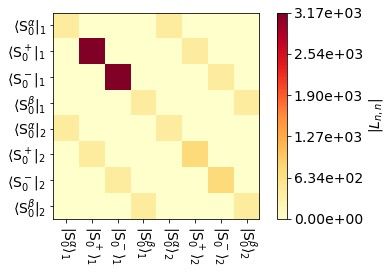

In [11]:
t_coal=1/(2*np.pi*(500-100))  #Correlation time for coalescence
L.kex=sl.Tools.twoSite_kex(tc=t_coal*3) #Puts us just into the slow-exchange regime.
_=L.plot(mode='abs')

The off-diagonal terms are introduced by the exchange matrix. Note what they do: they link a state in the upper left to the same state in the lower left, e.g. $S_0^\alpha$ in the upper left to $S_0^\alpha$ in the lower right. So exchange doesn't change the state of the system, it changes the interactions of the system given by the Liouvillian.

### Propagate the system
In order to propagate the system, we first need something to propagate! We generate a density matrix, `rho`. In SLEEPY, we must decide what state to start the system in when `rho` is generated, but also what to detect. Text-based arguments are accepted, e.g. `1Hx` would start all $^{1}$H in the system along the x-direction. We can also start on a specific spin, e.g. `S0z` would start in the z-direction on the 0$^{th}$ spin (the first spin, but according to Python convention, we number from zero). We often detect the $\hat{S}^+$ if we want to simulate spectra.

*Note:* SLEEPY also accepts numeric spin-matrices, which lets the user start in and detect arbitrary states of the spin-system, such as zero/double-quantum coherences, spin-order, etc.

In [12]:
rho=sl.Rho(rho0='S0x',detect='S0p')

We then generate a sequence followed by a propagator, `U`. We need to decide how long it should be. If we use spinning, then propagators will have a default length of one rotor period, but here, spinning was automatically turned off because we do not have any interactions that are affected by it, and so there is also no default propagator/sequence length.

Note that here, we don't add any radio-frequency irradiation; later, the sequence will allow us to define continuous or pulsed irradiation.

In [13]:
seq=L.Sequence(Dt=1/(4*500))
U=seq.U() 
#500 Hz is the largest chemical shift, so this time step will be short enough to avoid backfolding it.

To get a spectrum, we have to detect the state of the system, then propagate, then detect, then propagate, and so on. Detection in SLEEPY is done by *calling* the density matrix, i.e. `rho()`. Propagation is done by simply multiplying by a propagator (one can also multiply by a sequence, if that sequence has a defined length; this approach is computationally less efficient).

In [14]:
for k in range(1024):  #Run k over 1024 steps
    rho()     #Detect
    U*rho     #Propagate for a time Dt

Now, rho contains the signal for 1024 time points (`rho.I`). It also calculates the time from the beginning of the experiment of each detection (`rho.t_axis`). It also has the Fourier transformed signal (`rho.FT`), and the corresponding frequency axis (`rho.v_axis`). The user may use these for plotting or other further analysis. However, if we would just like to see the spectrum, we can run `rho.plot(FT=True)`, where `FT` determines whether to Fourier Transform the signal for a spectrum (`True`) or just show the time-trace (`False`).

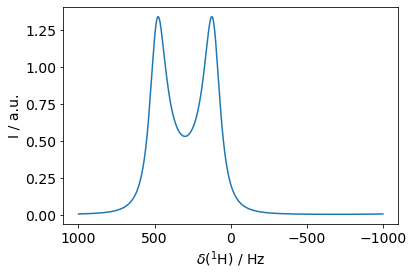

In [15]:
_=rho.plot(FT=True)

The for-loop above can be eliminated with additional SLEEPY functions. To demonstrate, we first clear the data out of `rho`, and then use the built-in `DetProp` function.

State-space reduction: 8->2


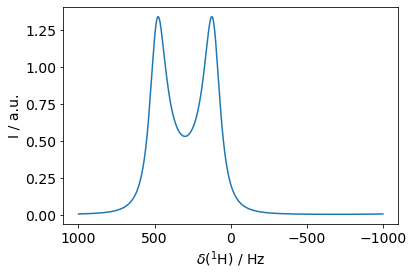

In [16]:
rho.clear()
rho.DetProp(U,n=1024)
_=rho.plot(FT=True)

The result is the same. `DetProp` is not only less to type, but it is also more efficient: it automatically reduces the matrix size wherever possible (see the message above: `State-space reduction: 8->2`, means that the 8x8 matrices were replaced with 2x2 matrices). It also uses eigenbasis propagation, which avoids a large number of matrix multiplications. Here we don't notice such a difference since the simulation is fairly small, but these features become critical elsehwere. Note that some experiments, however, for example REDOR with refocusing of the chemical shift, need to be done with the for-loop.

### Modify dynamics to view results
Below, we try a number of different correlation times, to see how it impacts the spectrum. We have previously calculated $\tau_{coalescence}$, which is the correlation time at which the two peaks merge into one. Here, we calculate for motion 10 times faster, 3 times faster, at coalescence, 3 times slower, and 10 times slower.

**Python tip:** `plt.subplots` sets up one figure with multiple axes, which we may then insert our plots into those axes. We tell it how many rows, how many columns, and optionally provide a size. `sharey=True` forces all y-axes to be the same for the plots, making it easier to compare the signal amplitudes.

**Python tip:** for-loops in python loop over any iterable. For example, we put all our desired correlation times into `tc0`, and put this in the for-loop, so we get a new `tc` at every step of the loop. However, we also have the 5 axes generated by `plt.subplots`, which we also want to loop over at the same time. We can loop over both by *zipping* them together, with the `zip` function.

State-space reduction: 8->2
State-space reduction: 8->2
State-space reduction: 8->2
State-space reduction: 8->2
State-space reduction: 8->2


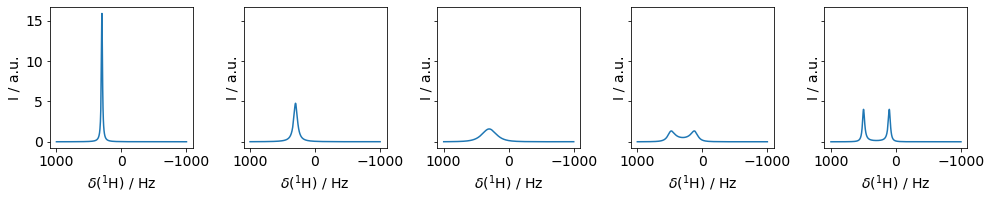

In [42]:
tc0=[t_coal/10,t_coal/3,t_coal,t_coal*3,t_coal*10]  #5 correlation times
fig,ax=plt.subplots(1,5,figsize=[14,3],sharey=True) #Creates figure with 5 axes to plot into
for tc,a in zip(tc0,ax):
    L.kex=sl.Tools.twoSite_kex(tc=tc)  #Reset the exchange matrix
    U=L.U(Dt=1/(4*500))
    rho.clear()  #Clear the density matrix
    rho.DetProp(U,n=1024)
    rho.plot(FT=True,ax=a)  #ax=a tells it where to plot the figure
fig.tight_layout()

**Fun(?) challenge:**

The following is just one (rather long) line of code. Can you see how it generates the results from above?

State-space reduction: 8->2


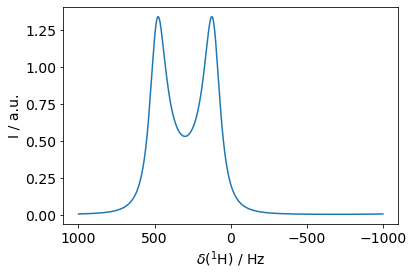

In [44]:
_=sl.Rho('S0x','S0p').DetProp(sl.Liouvillian(sl.ExpSys(500,Nucs='1H').set_inter('CS',i=0,Hz=500),
                                           sl.ExpSys(500,Nucs='1H').set_inter('CS',i=0,Hz=100),
                                           kex=sl.Tools.twoSite_kex(tc=3/(2*np.pi*400))).U(Dt=1/2000),
                                           n=1024).plot(FT=True)

## Example 2: $R_{1\rho}$ relaxation

A critical dynamics experiment in solid-state NMR is the $R_{1\rho}$ measurement (relaxation under a spin-lock). $R_{1\rho}$ relaxation in solids can be induced by reorientation of anisotropic interactions (e.g. CSA, dipole), but also in both solids and liquids by stochastic changes in the chemical shift. 

To simulate it, we need to introduce two systems, which have a CSA, dipole, and chemical shift. The CSA and dipole exhibit different orientations in the two systems, whereas the chemical shift changes its isotropic value.

### Define the experimental conditions

In [7]:
# Calculate size of the one-bond dipole coupling for H–N
delta=sl.Tools.dipole_coupling(.102,'15N','1H')  #Distance, nuc1, nuc2

# Define field, nuclei, spinning speed, powder average
ex0=sl.ExpSys(v0H=500,Nucs=['15N','1H'],vr=60000,pwdavg='rep320')
# This powder average is too big, and we'll change it later
# We want it here for displaying the couplings

# Define interactions (dipole, CSA, chemical shift)
ex0.set_inter('dipole',i0=0,i1=1,delta=delta)
ex0.set_inter('CSA',i=0,delta=113,euler_d=[0,23,0])
ex0.set_inter('CS',i=0,ppm=-5)

# Copy system
ex1=ex0.copy()
# Redefine dipole, CSA, with same magnitude, but different orientation (20 degree hop)
ex1.set_inter('dipole',i0=0,i1=1,delta=delta,euler_d=[0,20,45])  
ex1.set_inter('CSA',i=0,delta=113,euler_d=[[0,23,0],[0,20,45]])
# Redefine chemical shift, with 10 ppm change
_=ex1.set_inter('CS',i=0,ppm=5)

We can check what our motion looks like for the dipole and CSA couplings.

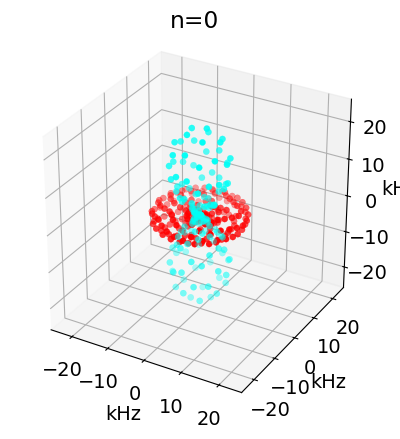

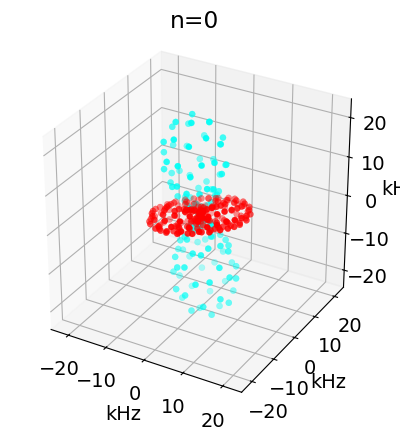

In [8]:
i=0  #0 for the dipole coupling, 1 for the CSA
ex0.plot_inter(i=0)
_=ex1.plot_inter(i=0)

In [9]:
ex0.pwdavg=2 #We used a larger powder average above to make nicer plots
# Here, we reduce the size for calculations, since we don't really need a big average

### Add dynamics, generate pulse sequence
We generate the Liouvillian as before, followed by the sequence. Now, however, we add a channel for irradiation on $^{15}$N. For $R_{1\rho}$ relaxation, this is continuous irradiation, and so all we need to do is define `v1`, the strength in Hz (it will be applied along the x-axis by default). A time axis may also be defined to set pulses with specific lengths, phases, strengths, and offsets, which we demonstrate later for the REDOR experiment.

Note that we can check what our pulse sequence looks like with `seq.plot()`, although it is not so useful here: it's just a constant field!

Now that we are spinning, the sequence obtains a default length of one rotor period. 

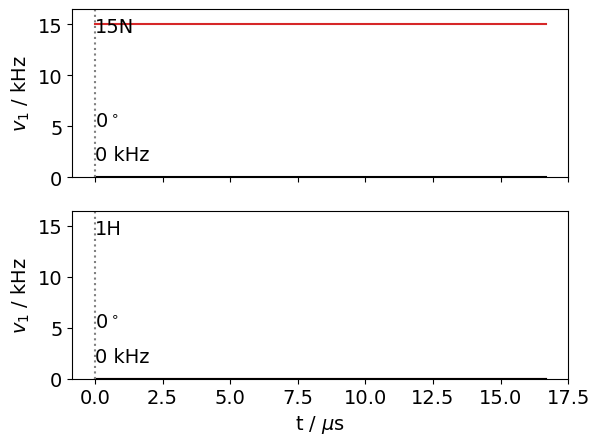

In [10]:
L=sl.Liouvillian(ex0,ex1,kex=sl.Tools.twoSite_kex(tc=1e-4))
seq=L.Sequence()
seq.add_channel('15N',v1=15000)
_=seq.plot()

### Propagate the system
**SLEEPY tip:** One can also provide `seq` to `rho.DetProp` directly, rather than first generating the propagator (`U=seq.U()`) and then inserting it. If you first generate the propagator, the result from calculating the propagator is saved into `U`, whereas if you use `seq`, then the propagator must be regenerated every time you use `seq`. However, providing `seq` lets one break the sequence into multiple propagation steps, allowing greater flexibility (e.g. if you want to obtain spinning sidebands). In the case below, we don't recycle the propagator, so it really doesn't make a difference.

State-space reduction: 32->16


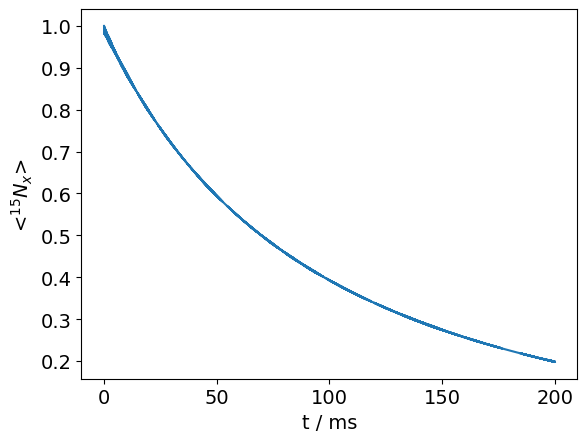

In [11]:
rho=sl.Rho('15Nx','15Nx')
rho.DetProp(seq,n=12000)
_=rho.plot()

### Check field-strength dependence
We sweep over multiple fields to see field-strength dependence. We use `rho.extract_decay_rates` to get the rates without explicit propagation. See [Rate Constant Extraction](RateConstantExtraction.ipynb) for more details on what this function does.

**Python tip:** Use `enumerate()` in the for loop to obtain a loop counter as one steps through the iterable (`v10` in the example here). Here, we're just using the counter to check the status of our calculation (since we do 29 simulations, it takes  little longer).

In [17]:
sl.Defaults['verbose']=False
v10=np.linspace(100,56100,29)
R1p=[]
rho=sl.Rho('15Nx','15Nx')
for k,v1 in enumerate(v10):
    if k%5==0:print(k)
    seq.add_channel('15N',v1=v1)
    R1p.append(rho.extract_decay_rates(seq))

0
5
10
15
20
25


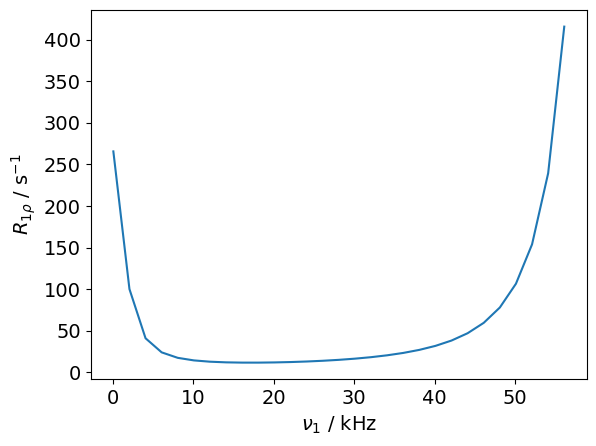

In [19]:
ax=plt.subplots()[1]
ax.plot(v10/1e3,R1p)
ax.set_xlabel(r'$\nu_1$ / kHz')
_=ax.set_ylabel(r'$R_{1\rho}$ / s$^{-1}$')

$R_{1\rho}$ relaxation due to reorientational dynamics is fastest as the spin-lock strength approaches the rotor frequency, so the fast relaxation near $\nu_1\approx$ 50 kHz comes from dipolar and CSA motion. On the other hand, relaxation due to chemical shift modulation occurs near $\nu_1=$ 0 kHz. We can see both effects in this field dependence.

## Example 3: REDOR (simplified)
In this example, we will simulate a pulse sequence (REDOR), which recouples the dipole coupling. We use this experiment in dynamics measurements to quantify amplitude of motion. Usually, we neglect its dependence on rate of motion, but this is not always correct (see [Aebischer et al.](https://mr.copernicus.org/articles/5/69/2024/)) which we can demonstrate here.

Note that the full REDOR sequence refocuses the chemical shift. For the sake of this tutorial, we will not include the chemical shift, and also skip the refocusing step, which simplifies the setup considerably. See the full setup with refocusing [here](http://sleepy-nmr.org/html/Chapter3/Ch3_REDOR.html).

### Define the experimental conditions
We'll use a methyl-hopping type motion. SLEEPY has a number of tools for setting up specific motions. We'll use one of these (`sl.Tools.Setup3siteSym`) to setup three-site symmetric exchange. This program defaults to a tetrahedral geometry for the exchange. These programs take a single ExpSys as argument, and create ExpSys copies with new geometry, and finally combine them into a Liouvillian with the appropriate geometry and exchange matrix. Inspect L after its creation.

In [83]:
delta=sl.Tools.dipole_coupling(.109,'13C','1H')  #Distance, nuc1, nuc2
ex0=sl.ExpSys(v0H=500,Nucs=['13C','1H'],vr=80000,n_gamma=30,pwdavg='bcr20')
ex0.set_inter('dipole',i0=0,i1=1,delta=delta)

L=sl.Tools.Setup3siteSym(ex0,tc=1e-7)
L

Liouvillian under the following conditions:
	2-spin system (13C,1H)
	B0 = 11.743 T (500.000 MHz 1H frequency)
	rotor angle = 54.736 degrees
	rotor frequency = 80.0 kHz
	Temperature = 298 K
	Powder Average: bcr20 with 600 angles

The individual Hamiltonians have the following interactions
	Hamiltonian #0
		dipole between spins 0,1 with arguments:
			(delta=46656.37,eta=0.00,euler=[0.00,0.00,0.00],[0.00,109.47,0.00])
	
	Hamiltonian #1
		dipole between spins 0,1 with arguments:
			(delta=46656.37,eta=0.00,euler=[0.00,0.00,0.00],[0.00,109.47,120.00])
	
	Hamiltonian #2
		dipole between spins 0,1 with arguments:
			(delta=46656.37,eta=0.00,euler=[0.00,0.00,0.00],[0.00,109.47,240.00])
	
	
Hamiltonians are coupled by exchange matrix:
	array([[-6666666.66666667,  3333333.33333333,  3333333.33333333],
	       [ 3333333.33333333, -6666666.66666667,  3333333.33333333],
	       [ 3333333.33333333,  3333333.33333333, -6666666.66666667]])


### Define the pulse sequence
We need two $\pi$-pulses, equally spaced within one rotor period. Note thet `L.taur` gives us the rotor period automatically.

array([<AxesSubplot:ylabel='$v_1$ / kHz'>,
       <AxesSubplot:xlabel='t / $\\mu$s', ylabel='$v_1$ / kHz'>],
      dtype=object)

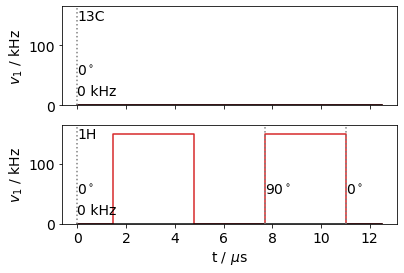

In [84]:
v1=150000 #Field strength on 1H
tpi=0.5/v1 #pi-pulse length
dly0=0.25*L.taur-tpi/2
seq=L.Sequence()
seq.add_channel('1H',t=[0,dly0,dly0+tpi,3*dly0+tpi,3*dly0+2*tpi,L.taur],v1=[0,v1,0,v1,0],phase=[0,0,0,np.pi/2,0])
seq.plot()

### Define density matrix and detection, propagate

In [85]:
rho=sl.Rho('13Cx','13Cx')
rho.DetProp(seq,n=75)

State-space reduction: 48->24


Density Matrix/Detection Operator
rho0: 13Cx
detect[0]: 13Cx
Current time is 937.500 microseconds
75 time points have been recorded


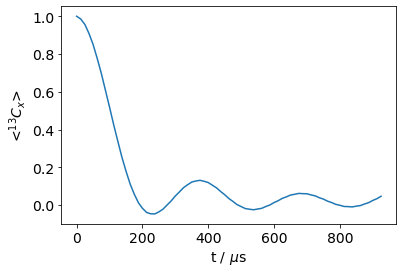

In [86]:
_=rho.plot()

Now, slow down the motion and see what changes!

State-space reduction: 48->24


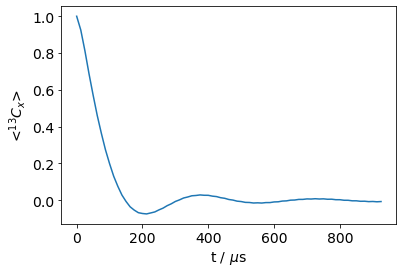

In [87]:
L.kex=sl.Tools.nSite_sym(3,tc=1e-5)
rho.clear()
rho.DetProp(seq,n=75)
_=rho.plot()

State-space reduction: 48->24


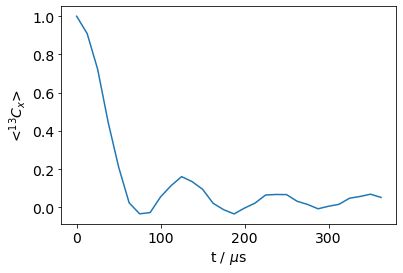

In [88]:
L.kex=sl.Tools.nSite_sym(3,tc=5e-4)
rho.clear()
rho.DetProp(seq,n=30)
_=rho.plot()

## Example 4: $T_1$ and NOE in the Lab Frame

State-space reduction: 480->120


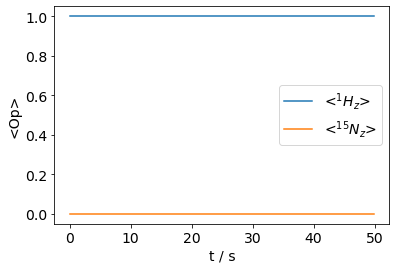

In [168]:
ex0=sl.ExpSys(500,Nucs=['1H','15N'],LF=False)
ex0.set_inter('dipole',i0=0,i1=1,delta=sl.Tools.dipole_coupling(.102,'1H','15N'))
# ex0.set_inter('CSA',i=1,delta=113*3/2,euler_d=[0,20,0])
L=sl.Tools.SetupTumbling(ex0,q=4,tc=1e-10)

U=L.U(Dt=.1)

rho=sl.Rho('1Hz',['1Hz','15Nz'])

rho.DetProp(U,n=500)
ax=rho.plot()

<AxesSubplot:xlabel='t / s', ylabel='<Op>'>

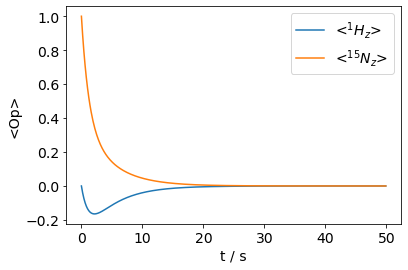

In [102]:
rho=sl.Rho('15Nz',['1Hz','15Nz'])

rho.DetProp(U,n=500)
rho.plot()